# EDA: merge-boundary coverage

Notebook này chỉ đo coverage của boundary bằng đúng OpenCV helpers đang dùng ở inference. Nó không ghi file prediction và không thay đổi threshold.

Chạy tuần tự các cell. Cell sweep H là cell quyết định threshold ngang; V chỉ là chẩn đoán bổ sung.

In [8]:
import json
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import unicodedata

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve().parent
if not (ROOT / 'data' / 'training_set' / 'manifest.jsonl').is_file():
    raise FileNotFoundError('Không tìm thấy data/training_set/manifest.jsonl; mở notebook từ thư mục Doc2Table/notebooks.')

TRAIN_DIR = ROOT / 'data' / 'training_set'
records = [json.loads(line) for line in (TRAIN_DIR / 'manifest.jsonl').read_text(encoding='utf-8').splitlines() if line]
print(f'ROOT={ROOT} | documents={len(records)}')

ROOT=e:\AIO\Project\Doc2Table\TACVU2 | documents=1100


In [9]:
# Minimal self-contained copies of the inference parser and grid detector.

def split_markdown_row(line: str) -> list[str]:
    if not (line.startswith('|') and line.endswith('|')):
        raise ValueError('Invalid Markdown row')
    cells, current, escaped = [], [], False
    for character in line[1:-1]:
        if escaped:
            current.append('\\' + character)
            escaped = False
        elif character == '\\':
            escaped = True
        elif character == '|':
            cells.append(''.join(current).strip())
            current = []
        else:
            current.append(character)
    if escaped:
        current.append('\\')
    cells.append(''.join(current).strip())
    return cells


def parse_markdown(markdown: str) -> list[list[list[str]]]:
    tables = []
    for block in unicodedata.normalize('NFC', markdown).strip().split('\n\n'):
        rows = [split_markdown_row(line.strip()) for line in block.splitlines() if line.strip()]
        if len(rows) < 3 or any(len(row) != len(rows[0]) for row in rows) or any(cell != '---' for cell in rows[1]):
            raise ValueError('Invalid Markdown table')
        tables.append([rows[0], *rows[2:]])
    return tables


@dataclass(frozen=True)
class GridTable:
    bbox: tuple[int, int, int, int]
    x_edges: tuple[int, ...]
    y_edges: tuple[int, ...]

    @property
    def rows(self) -> int:
        return len(self.y_edges) - 1

    @property
    def cols(self) -> int:
        return len(self.x_edges) - 1


def _runs(mask: np.ndarray, minimum: int = 1, gap: int = 2) -> list[tuple[int, int]]:
    indices = np.flatnonzero(mask)
    if indices.size == 0:
        return []
    result, start, previous = [], int(indices[0]), int(indices[0])
    for raw in indices[1:]:
        value = int(raw)
        if value - previous > gap:
            if previous - start + 1 >= minimum:
                result.append((start, previous))
            start = value
        previous = value
    if previous - start + 1 >= minimum:
        result.append((start, previous))
    return result


def load_gray(path: Path) -> np.ndarray:
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f'Cannot read image: {path}')
    return gray


def binarize(gray: np.ndarray) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    return cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]


def line_masks(binary: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = binary.shape
    horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (max(45, width // 18), 1)))
    vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(35, height // 45))))
    return horizontal, vertical


def _line_positions(mask: np.ndarray, axis: int, extent: int) -> list[int]:
    projection = np.count_nonzero(mask, axis=axis)
    positions = []
    for start, end in _runs(projection >= max(8, round(extent * 0.42)), gap=3):
        positions.extend((start, end)) if end - start >= 9 else positions.append(round((start + end) / 2))
    return positions


def _dedupe(values: list[int], tolerance: int = 6) -> list[int]:
    groups = []
    for value in values:
        if groups and value - groups[-1][-1] <= tolerance:
            groups[-1].append(value)
        else:
            groups.append([value])
    return [round(sum(group) / len(group)) for group in groups]


def _segment_coverage(mask: np.ndarray, fixed: int, start: int, end: int, vertical: bool, radius: int = 2, trim: int = 3) -> float:
    start, end = start + trim, end - trim
    if end <= start:
        return 1.0
    if vertical:
        band = mask[start:end, max(0, fixed - radius):min(mask.shape[1], fixed + radius + 1)]
        return float(np.any(band > 0, axis=1).mean())
    band = mask[max(0, fixed - radius):min(mask.shape[0], fixed + radius + 1), start:end]
    return float(np.any(band > 0, axis=0).mean())


def _vertical_endpoint_connectivity(mask: np.ndarray, fixed: int, start: int, end: int, radius: int = 2, endpoint_radius: int = 3) -> float:
    """Fraction of the two horizontal grid-line endpoints touched by the vertical mask."""
    x0, x1 = max(0, fixed - radius), min(mask.shape[1], fixed + radius + 1)
    top = np.any(mask[max(0, start - endpoint_radius):min(mask.shape[0], start + endpoint_radius + 1), x0:x1] > 0)
    bottom = np.any(mask[max(0, end - endpoint_radius):min(mask.shape[0], end + endpoint_radius + 1), x0:x1] > 0)
    return (float(top) + float(bottom)) / 2


assert _vertical_endpoint_connectivity(np.array([[0, 255], [0, 255]], dtype=np.uint8), 0, 0, 1, radius=1, endpoint_radius=0) == 1.0


def detect_grid_tables(gray: np.ndarray) -> list[GridTable]:
    binary = binarize(gray)
    horizontal, vertical = line_masks(binary)
    joined = cv2.dilate(cv2.bitwise_or(horizontal, vertical), cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)), iterations=1)
    contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    height, width = gray.shape
    candidates = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w < width * 0.48 or h < 80 or w * h < width * height * 0.012:
            continue
        x0, y0, x1, y1 = max(0, x - 4), max(0, y - 4), min(width, x + w + 4), min(height, y + h + 4)
        xs = _dedupe([x0 + value for value in _line_positions(vertical[y0:y1, x0:x1], axis=0, extent=y1-y0)])
        # Horizontal-line projection spans the table width; keep this identical to inference.
        ys = _dedupe([y0 + value for value in _line_positions(horizontal[y0:y1, x0:x1], axis=1, extent=x1-x0)])
        if len(xs) < 3 or len(ys) < 3:
            continue
        if abs(xs[0] - x) > 10: xs.insert(0, x)
        if abs(xs[-1] - (x + w - 1)) > 10: xs.append(x + w - 1)
        if abs(ys[0] - y) > 10: ys.insert(0, y)
        if abs(ys[-1] - (y + h - 1)) > 10: ys.append(y + h - 1)
        if 2 <= len(xs) - 1 <= 18 and 2 <= len(ys) - 1 <= 60:
            candidates.append(GridTable((x, y, x + w, y + h), tuple(xs), tuple(ys)))
    candidates.sort(key=lambda item: (item.bbox[1], item.bbox[0], -item.rows * item.cols))
    kept = []
    for table in candidates:
        x0, y0, x1, y1 = table.bbox
        area, duplicate = max(1, (x1-x0) * (y1-y0)), False
        for previous in kept:
            a0, b0, a1, b1 = previous.bbox
            intersection = max(0, min(x1, a1)-max(x0, a0)) * max(0, min(y1, b1)-max(y0, b0))
            if intersection / min(area, max(1, (a1-a0) * (b1-b0))) > 0.72:
                duplicate = True
                break
        if not duplicate:
            kept.append(table)
    return kept


assert parse_markdown('| A | B |\n| --- | --- |\n| x | y |') == [[['A', 'B'], ['x', 'y']]]
print('Loaded self-contained Markdown parser and OpenCV grid helpers')

Loaded self-contained Markdown parser and OpenCV grid helpers


In [10]:
def region_ids(markdown: list[list[str]]) -> list[list[int]]:
    """Map each atomic cell to its GT merge component."""
    rows, cols = len(markdown), len(markdown[0])
    parent = list(range(rows * cols))

    def find(node: int) -> int:
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    def union(left: int, right: int) -> None:
        left, right = find(left), find(right)
        if left != right:
            parent[right] = left

    for row in range(rows):
        for col in range(cols):
            marker = markdown[row][col]
            node = row * cols + col
            if marker == '[[H]]':
                union(node, node - 1)
            elif marker == '[[V]]':
                union(node, node - cols)
    return [[find(row * cols + col) for col in range(cols)] for row in range(rows)]


def _region_ids_self_check() -> None:
    ids = region_ids([['A', '[[H]]'], ['[[V]]', '[[V]]']])
    assert len({value for row in ids for value in row}) == 1


_region_ids_self_check()

In [11]:
# Collect both axes in one pass. This matches inference: no deskew.
coverage_rows = []
skipped = Counter()

for record in tqdm((record for record in records if record['difficulty'] in {'M1', 'M2'}), desc='Coverage EDA', unit='doc'):
    attributes = record['attributes']
    group = f"{attributes['table_count']}T{attributes['page_count']}P"
    for image_rel, label_rel in zip(record['image_paths'], record['page_label_paths'], strict=True):
        gray = load_gray(TRAIN_DIR / image_rel)
        binary = binarize(gray)
        horizontal, vertical = line_masks(binary)
        detected, ground_truth = detect_grid_tables(gray), parse_markdown((TRAIN_DIR / label_rel).read_text(encoding='utf-8'))
        if len(detected) != len(ground_truth):
            skipped['table-count'] += 1
            continue
        for table_id, (grid, markdown) in enumerate(zip(detected, ground_truth, strict=True)):
            if grid.rows != len(markdown) or grid.cols != len(markdown[0]):
                skipped['grid-shape'] += 1
                continue
            ids = region_ids(markdown)
            common = {'doc_id': record['id'], 'page': image_rel, 'difficulty': record['difficulty'],
                      'group': group, 'table_id': table_id}
            for row in range(grid.rows):
                for col in range(grid.cols - 1):
                    coverage_rows.append({**common, 'axis': 'vertical', 'row': row, 'boundary_col': col + 1, 'coverage': _segment_coverage(
                        vertical, grid.x_edges[col + 1], grid.y_edges[row], grid.y_edges[row + 1], vertical=True),
                        'endpoint_connectivity': _vertical_endpoint_connectivity(
                            vertical, grid.x_edges[col + 1], grid.y_edges[row], grid.y_edges[row + 1]),
                        'class': 'H-merge' if ids[row][col] == ids[row][col + 1] else 'separator'})
            for row in range(grid.rows - 1):
                for col in range(grid.cols):
                    coverage_rows.append({**common, 'axis': 'horizontal', 'row': row + 1, 'boundary_col': col, 'coverage': _segment_coverage(
                        horizontal, grid.y_edges[row + 1], grid.x_edges[col], grid.x_edges[col + 1], vertical=False),
                        'class': 'V-merge' if ids[row][col] == ids[row + 1][col] else 'separator'})

coverage_df = pd.DataFrame(coverage_rows)
vertical_df = coverage_df.query("axis == 'vertical'").copy()
horizontal_df = coverage_df.query("axis == 'horizontal'").copy()
print(f'boundaries={len(coverage_df):,} | vertical={len(vertical_df):,} | horizontal={len(horizontal_df):,}')
print('skipped pages:', dict(skipped))
display(vertical_df.groupby(['difficulty', 'class'])['coverage'].describe())

Coverage EDA: 655doc [01:07,  9.75doc/s]


boundaries=129,001 | vertical=62,383 | horizontal=66,618
skipped pages: {}


count      mean       std  min  25%  50%  75%  max
difficulty class                                                          
M1         separator  10012.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0
M2         H-merge     6438.0  0.460851  0.488443  0.0  0.0  0.0  1.0  1.0
           separator  45933.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0

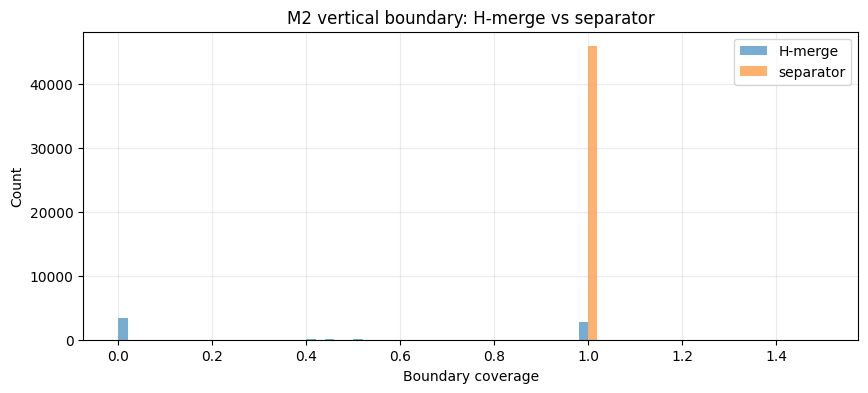

,threshold,precision,recall,f1,m1_false_merge_rate,tp,fp,fn
16,0.85,1.0,0.557937,0.716251,0.0,3592,0,2846
18,0.95,1.0,0.557937,0.716251,0.0,3592,0,2846
15,0.80,1.0,0.557937,0.716251,0.0,3592,0,2846
13,0.70,1.0,0.557937,0.716251,0.0,3592,0,2846
14,0.75,1.0,0.557937,0.716251,0.0,3592,0,2846
12,0.65,1.0,0.557937,0.716251,0.0,3592,0,2846
17,0.90,1.0,0.557937,0.716251,0.0,3592,0,2846
11,0.60,1.0,0.557471,0.715867,0.0,3589,0,2849
10,0.55,1.0,0.553899,0.712915,0.0,3566,0,2872
9,0.50,1.0,0.544890,0.705409,0.0,3508,0,2930


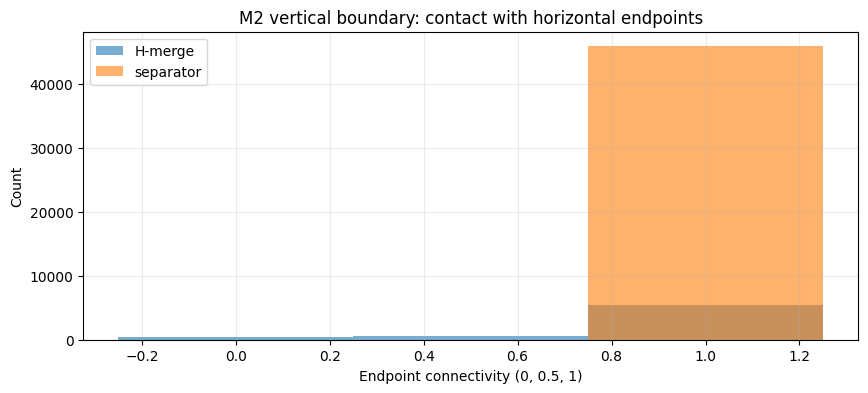

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
H-merge,6438.0,0.896086,0.262776,0.0,1.0,1.0,1.0,1.0
separator,45933.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


Candidate rule: separator = coverage >= coverage_threshold AND endpoint_connectivity >= endpoint_threshold


,coverage_threshold,endpoint_threshold,precision,recall,f1,separator_false_merge_rate
1,0.05,1.0,1.0,0.557937,0.716251,0.0
3,0.10,1.0,1.0,0.557937,0.716251,0.0
5,0.15,1.0,1.0,0.557937,0.716251,0.0
7,0.20,1.0,1.0,0.557937,0.716251,0.0
9,0.25,1.0,1.0,0.557937,0.716251,0.0
11,0.30,1.0,1.0,0.557937,0.716251,0.0
13,0.35,1.0,1.0,0.557937,0.716251,0.0
15,0.40,1.0,1.0,0.557937,0.716251,0.0
17,0.45,1.0,1.0,0.557937,0.716251,0.0
19,0.50,1.0,1.0,0.557937,0.716251,0.0


In [12]:
def plot_and_sweep(frame: pd.DataFrame, merge_label: str, title: str) -> pd.DataFrame:
    m2 = frame.query("difficulty == 'M2'")
    plt.figure(figsize=(10, 4))
    for label in (merge_label, 'separator'):
        plt.hist(m2.loc[m2['class'] == label, 'coverage'], bins=50, alpha=0.6, label=label)
    plt.xlabel('Boundary coverage')
    plt.ylabel('Count')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    rows = []
    for threshold in np.arange(0.05, 0.96, 0.05):
        predicted = m2['coverage'] < threshold
        expected = m2['class'].eq(merge_label)
        tp, fp, fn = int((predicted & expected).sum()), int((predicted & ~expected).sum()), int((~predicted & expected).sum())
        precision, recall = tp / max(1, tp + fp), tp / max(1, tp + fn)
        m1_false_merge = float((frame.query("difficulty == 'M1'")['coverage'] < threshold).mean())
        rows.append({'threshold': threshold, 'precision': precision, 'recall': recall,
                     'f1': 2 * precision * recall / max(1e-12, precision + recall),
                     'm1_false_merge_rate': m1_false_merge, 'tp': tp, 'fp': fp, 'fn': fn})
    return pd.DataFrame(rows).sort_values('f1', ascending=False)


h_sweep = plot_and_sweep(vertical_df, 'H-merge', 'M2 vertical boundary: H-merge vs separator')
display(h_sweep.head(10))

# A separator must be present along its length and touch its horizontal grid-line endpoints.
m2_vertical = vertical_df.query("difficulty == 'M2'").copy()
plt.figure(figsize=(10, 4))
for label in ('H-merge', 'separator'):
    plt.hist(m2_vertical.loc[m2_vertical['class'] == label, 'endpoint_connectivity'], bins=3, range=(-0.25, 1.25), alpha=0.6, label=label)
plt.xlabel('Endpoint connectivity (0, 0.5, 1)')
plt.ylabel('Count')
plt.title('M2 vertical boundary: contact with horizontal endpoints')
plt.legend(); plt.grid(alpha=0.25); plt.show()
display(m2_vertical.groupby('class')['endpoint_connectivity'].describe())

joint_rows = []
for coverage_threshold in np.arange(0.05, 1.00, 0.05):
    for endpoint_threshold in (0.5, 1.0):
        separator = (m2_vertical['coverage'] >= coverage_threshold) & (m2_vertical['endpoint_connectivity'] >= endpoint_threshold)
        predicted_merge = ~separator
        expected_merge = m2_vertical['class'].eq('H-merge')
        tp, fp, fn = int((predicted_merge & expected_merge).sum()), int((predicted_merge & ~expected_merge).sum()), int((~predicted_merge & expected_merge).sum())
        precision, recall = tp / max(1, tp + fp), tp / max(1, tp + fn)
        joint_rows.append({'coverage_threshold': coverage_threshold, 'endpoint_threshold': endpoint_threshold,
                           'precision': precision, 'recall': recall,
                           'f1': 2 * precision * recall / max(1e-12, precision + recall),
                           'separator_false_merge_rate': fp / max(1, int((~expected_merge).sum()))})

h_joint_sweep = pd.DataFrame(joint_rows).sort_values(['f1', 'separator_false_merge_rate'], ascending=[False, True])
print('Candidate rule: separator = coverage >= coverage_threshold AND endpoint_connectivity >= endpoint_threshold')
display(h_joint_sweep.head(10))

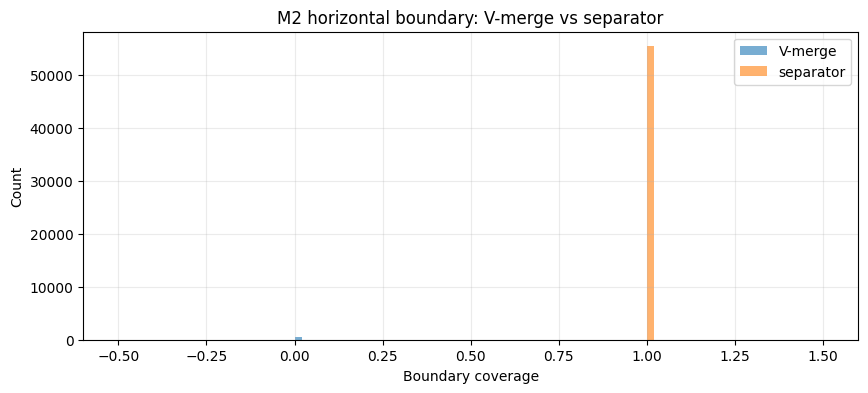

,threshold,precision,recall,f1,m1_false_merge_rate,tp,fp,fn
0,0.05,1.0,1.0,1.0,0.0,422,0,0
1,0.10,1.0,1.0,1.0,0.0,422,0,0
2,0.15,1.0,1.0,1.0,0.0,422,0,0
3,0.20,1.0,1.0,1.0,0.0,422,0,0
4,0.25,1.0,1.0,1.0,0.0,422,0,0
5,0.30,1.0,1.0,1.0,0.0,422,0,0
6,0.35,1.0,1.0,1.0,0.0,422,0,0
7,0.40,1.0,1.0,1.0,0.0,422,0,0
8,0.45,1.0,1.0,1.0,0.0,422,0,0
9,0.50,1.0,1.0,1.0,0.0,422,0,0


In [13]:
# Optional V-merge diagnostic. Do not tune the vertical threshold until H has been validated.
v_sweep = plot_and_sweep(horizontal_df, 'V-merge', 'M2 horizontal boundary: V-merge vs separator')
display(v_sweep.head(10))

In [14]:
# Stratified GT H-merge false negatives with an almost-full detected line.
high_coverage_h_fn = vertical_df.query("difficulty == 'M2' and `class` == 'H-merge' and coverage > 0.95").copy()
high_coverage_h_fn['row_type'] = np.where(high_coverage_h_fn['row'] < 3, 'header', 'data')
samples_per_bucket = 8
fn_h_samples = (high_coverage_h_fn.groupby(['group', 'row_type'], group_keys=False)
                .apply(lambda frame: frame.sample(min(samples_per_bucket, len(frame)), random_state=2026))
                .sort_values(['group', 'row_type', 'doc_id', 'page', 'table_id', 'row', 'boundary_col'])
                .reset_index(drop=True))
print(f'high-coverage H false negatives: {len(high_coverage_h_fn):,} | selected: {len(fn_h_samples)}')
display(fn_h_samples[['doc_id', 'page', 'group', 'row_type', 'table_id', 'row', 'boundary_col', 'coverage']])

high-coverage H false negatives: 2,846 | selected: 24


C:\Users\minhtq\AppData\Local\Temp\ipykernel_29784\3010193912.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(min(samples_per_bucket, len(frame)), random_state=2026))


,doc_id,page,group,row_type,table_id,row,boundary_col,coverage
0,train-00326,images/train-00326_p01.jpg,1T1P,header,0,0,2,1.0
1,train-00338,images/train-00338_p01.jpg,1T1P,header,0,0,6,1.0
2,train-00348,images/train-00348_p01.jpg,1T1P,header,0,0,1,1.0
3,train-00348,images/train-00348_p01.jpg,1T1P,header,0,0,6,1.0
4,train-00465,images/train-00465_p01.jpg,1T1P,header,0,0,4,1.0
5,train-00534,images/train-00534_p01.jpg,1T1P,header,0,0,4,1.0
6,train-00559,images/train-00559_p01.jpg,1T1P,header,0,0,8,1.0
7,train-00578,images/train-00578_p01.jpg,1T1P,header,0,0,3,1.0
8,train-00334,images/train-00334_p02.jpg,1T2P,header,0,0,8,1.0
9,train-00342,images/train-00342_p02.jpg,1T2P,header,0,0,5,1.0


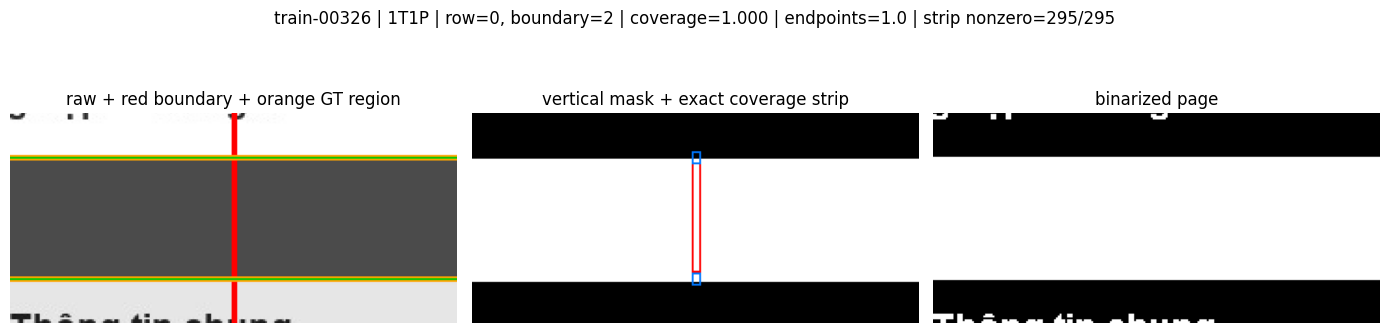

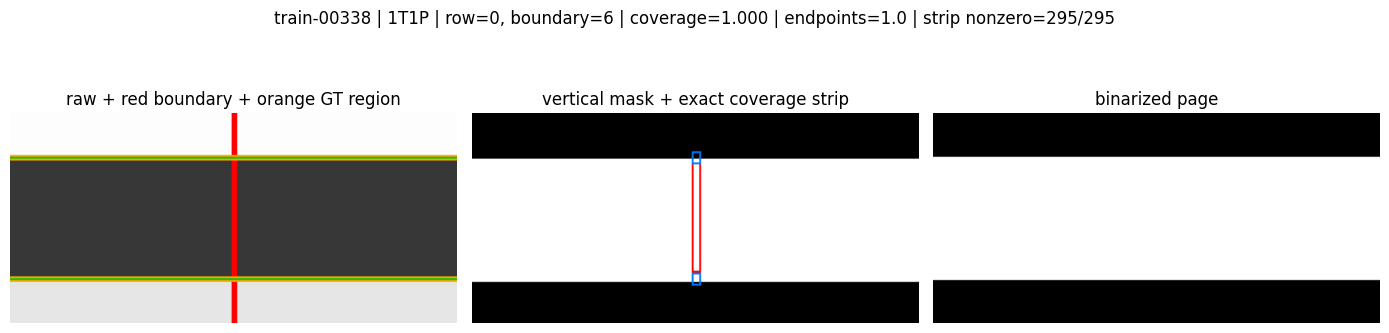

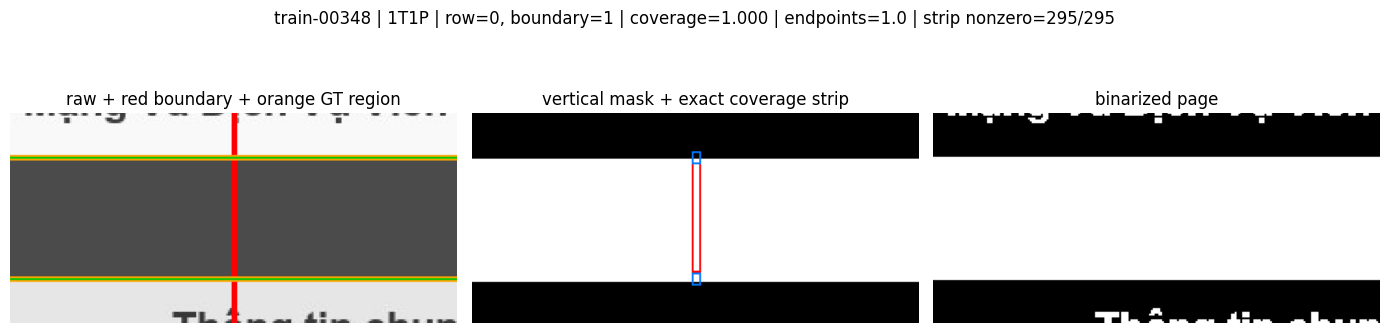

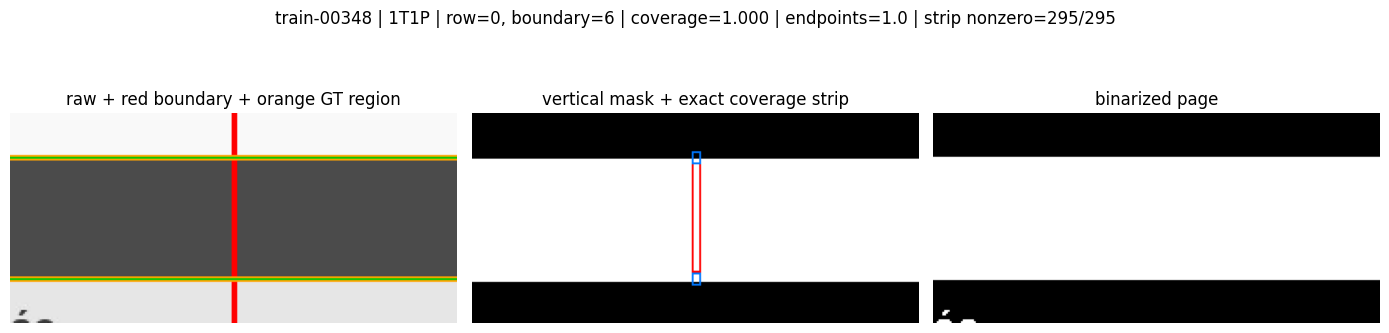

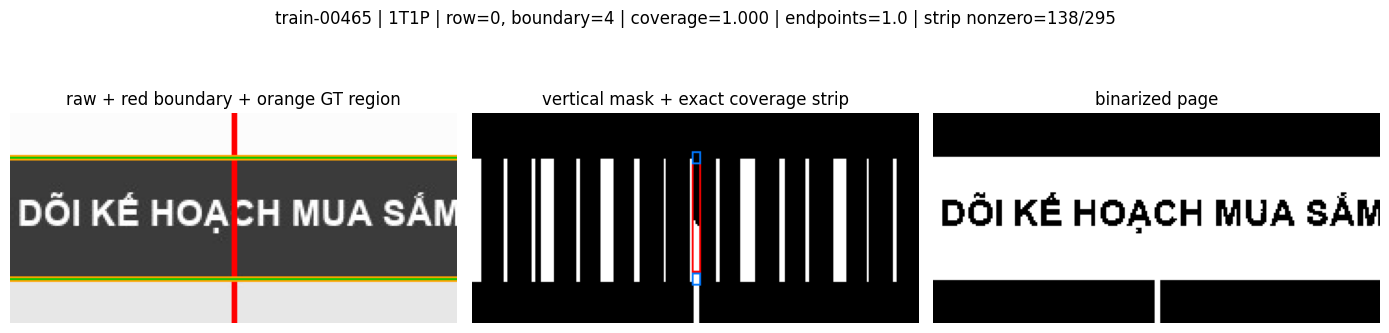

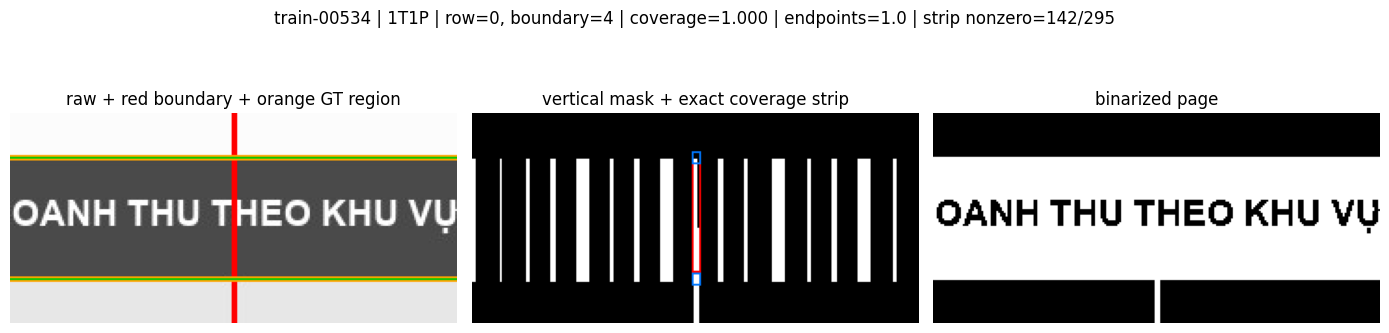

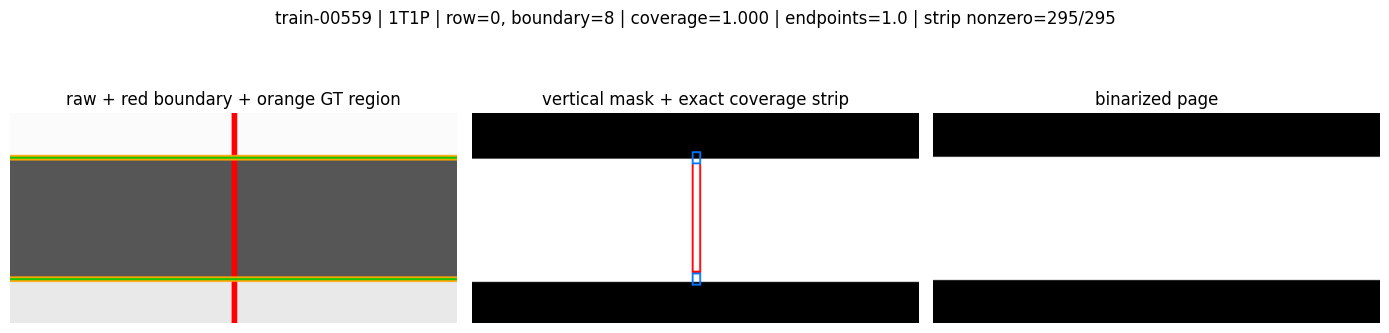

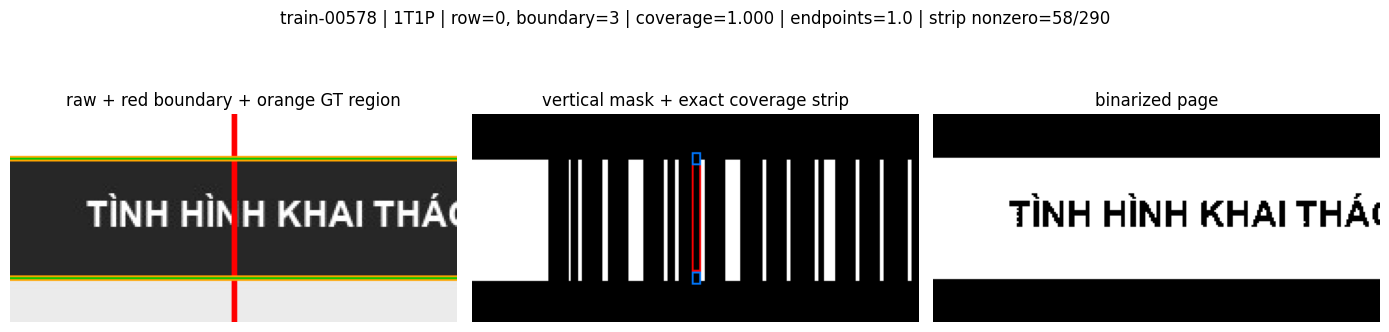

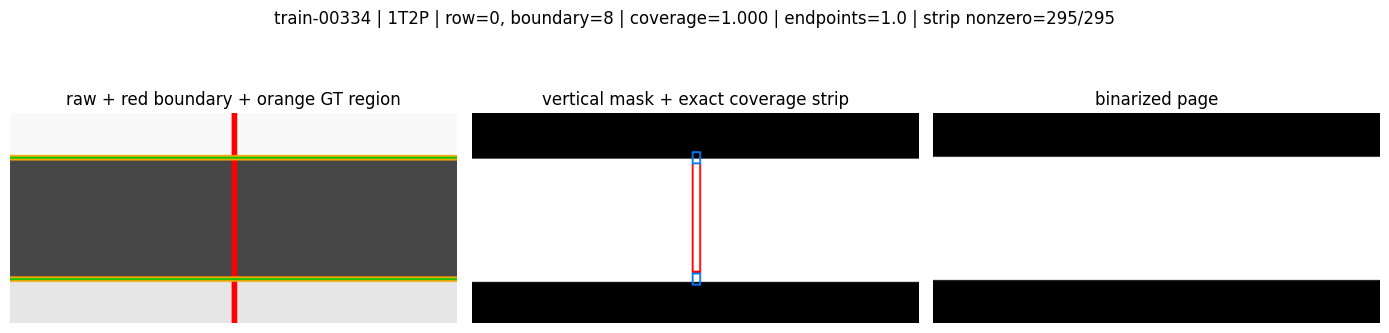

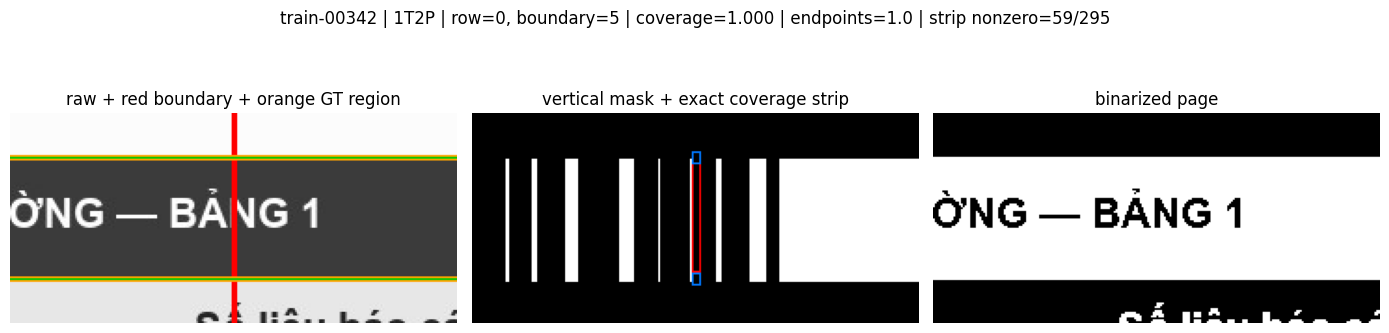

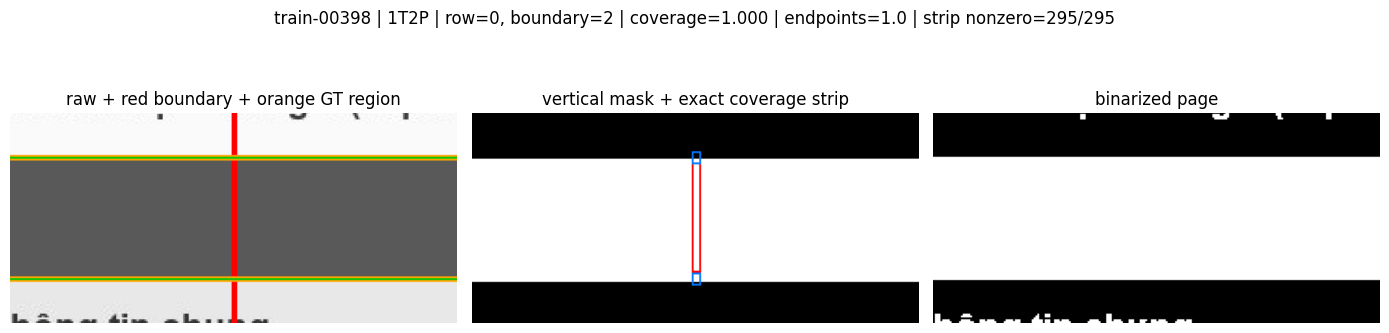

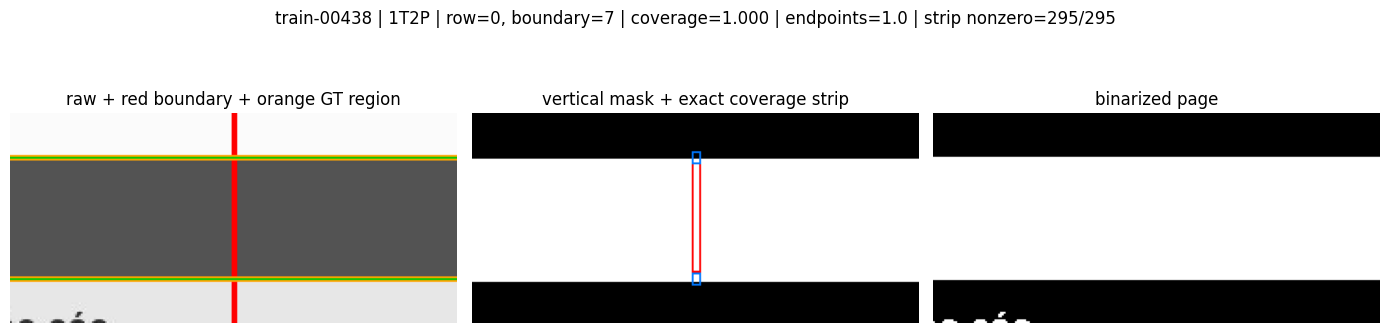

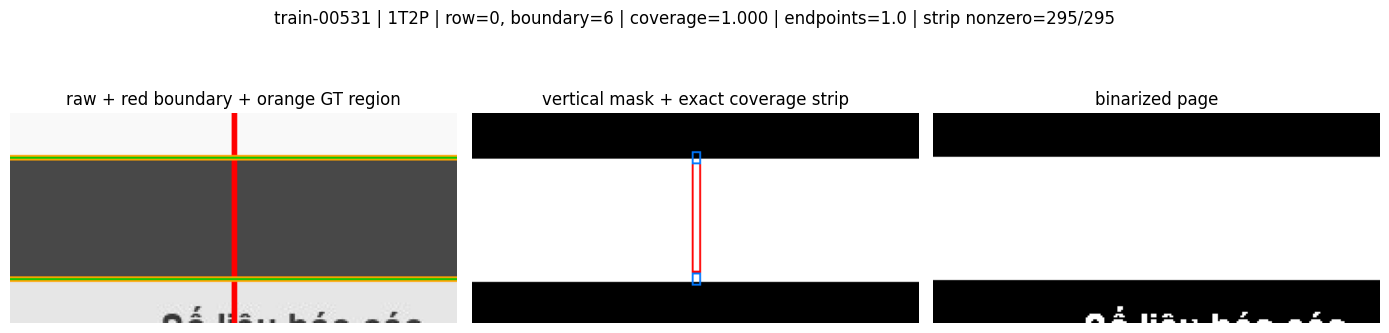

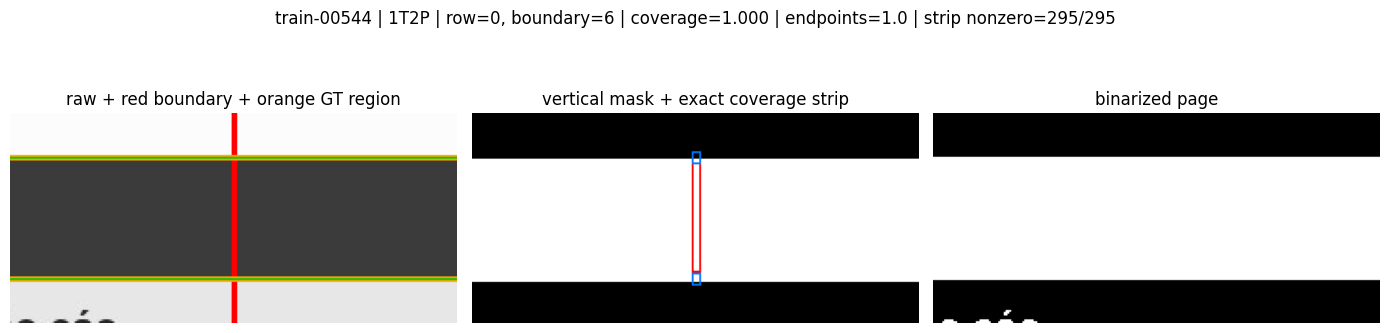

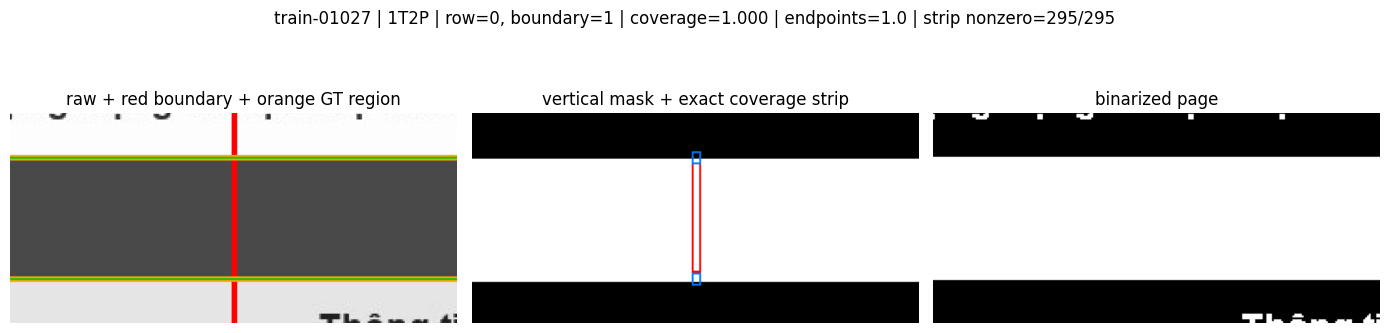

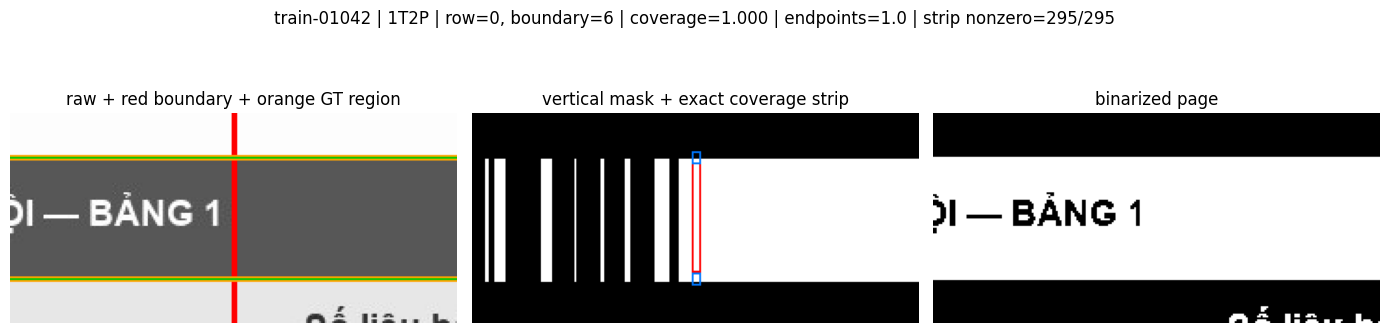

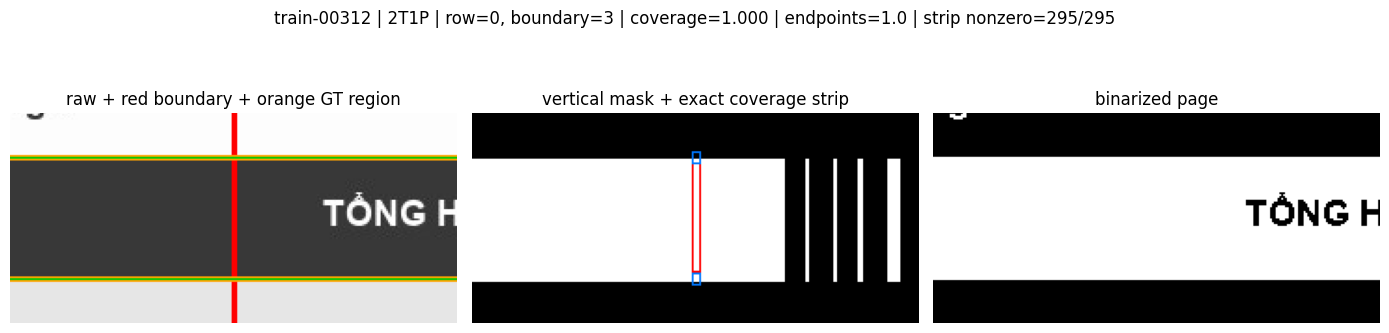

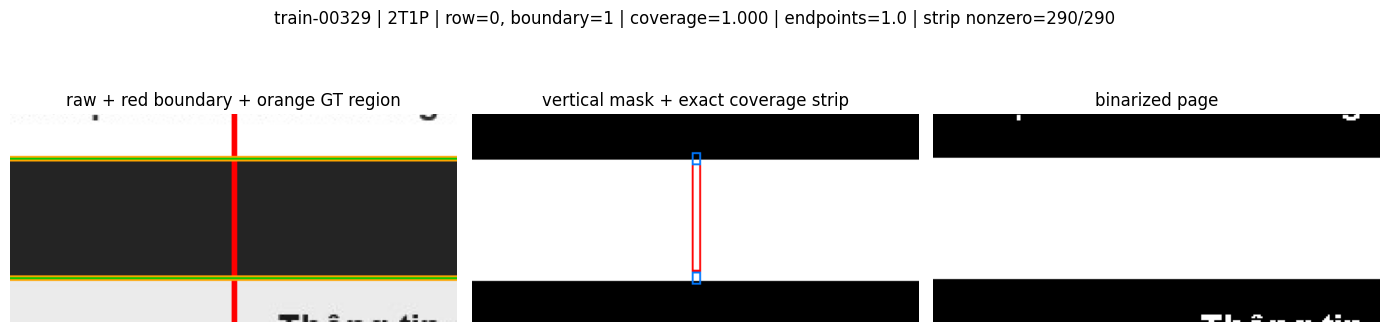

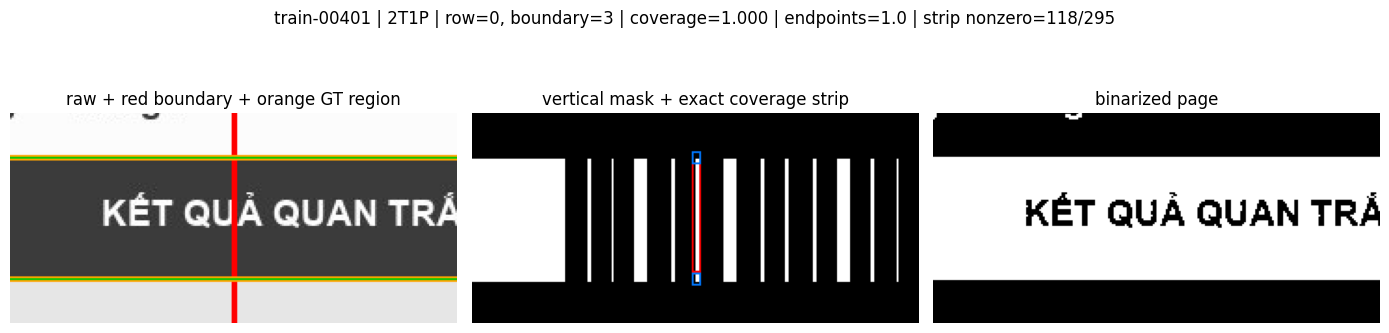

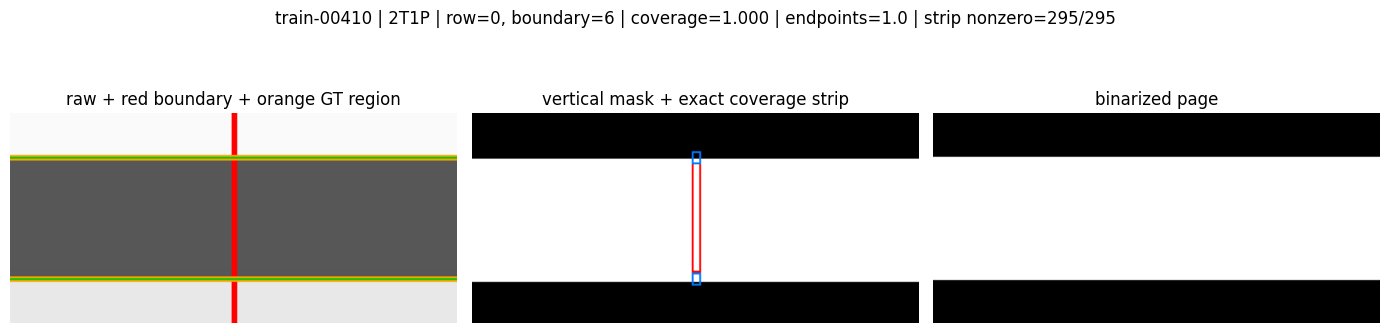

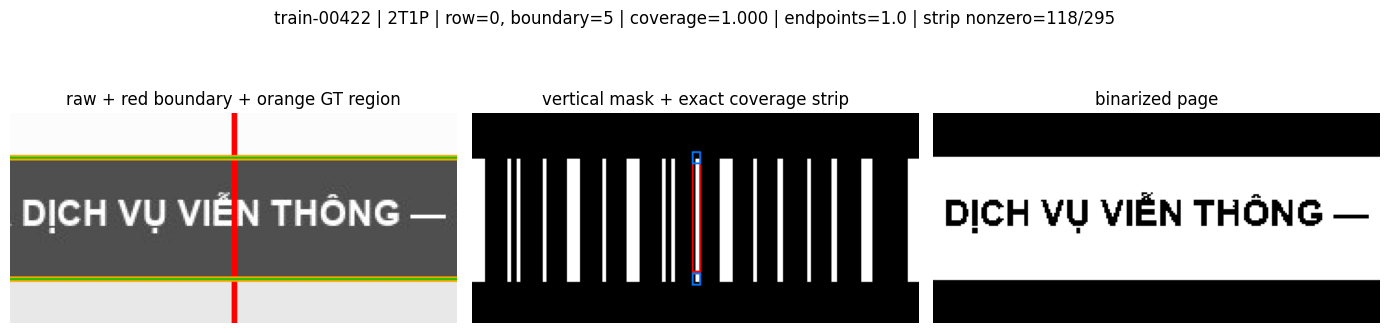

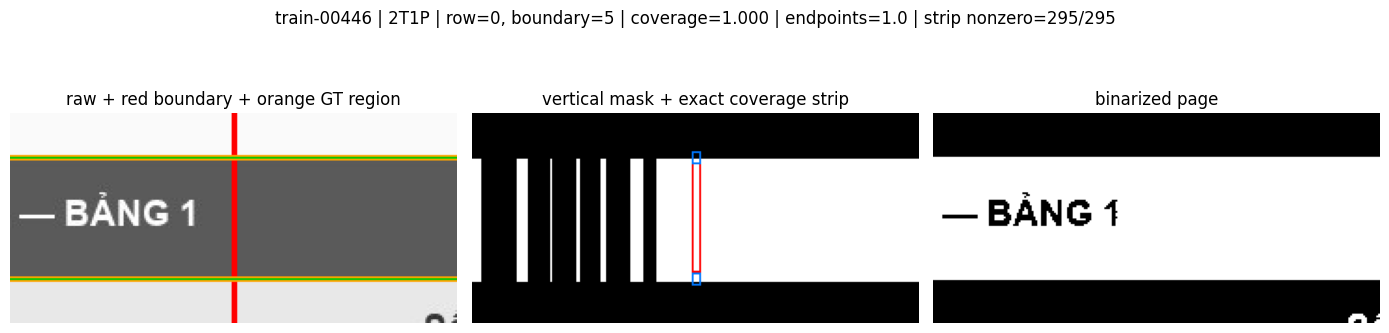

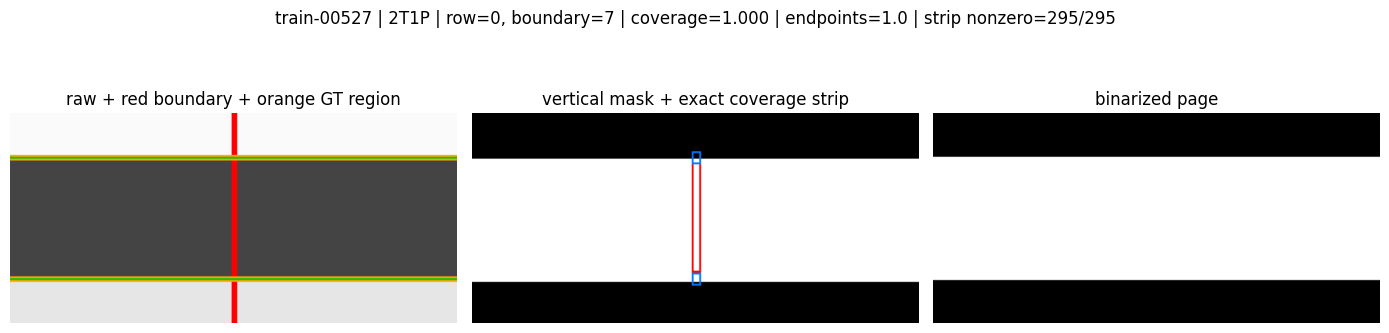

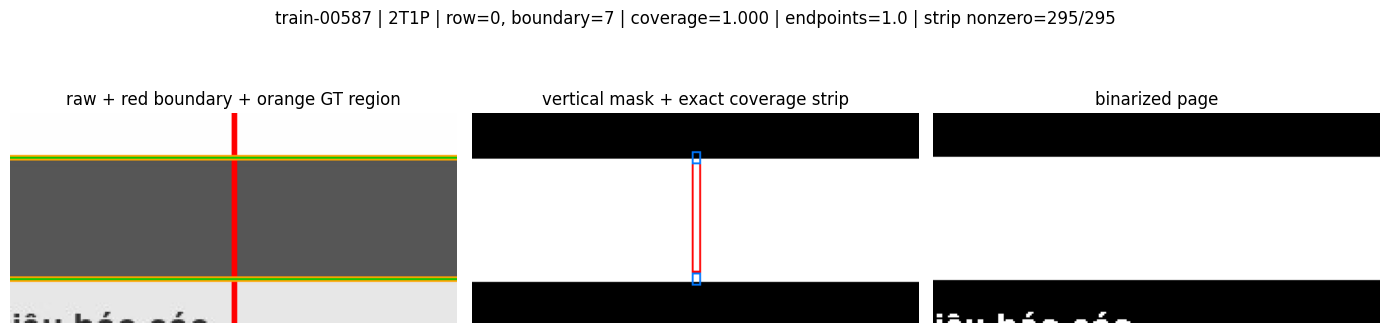

In [15]:
records_by_id = {record['id']: record for record in records}

def show_h_false_negative(sample: pd.Series) -> None:
    record = records_by_id[sample.doc_id]
    page_index = record['image_paths'].index(sample.page)
    gray = load_gray(TRAIN_DIR / sample.page)
    binary = binarize(gray)
    _, vertical = line_masks(binary)
    grid = detect_grid_tables(gray)[int(sample.table_id)]
    markdown = parse_markdown((TRAIN_DIR / record['page_label_paths'][page_index]).read_text(encoding='utf-8'))[int(sample.table_id)]
    ids = region_ids(markdown)
    row, boundary = int(sample.row), int(sample.boundary_col)
    region = ids[row][boundary - 1]
    members = [(r, c) for r in range(grid.rows) for c in range(grid.cols) if ids[r][c] == region]
    r0, r1 = min(r for r, _ in members), max(r for r, _ in members) + 1
    c0, c1 = min(c for _, c in members), max(c for _, c in members) + 1
    x, y0, y1 = grid.x_edges[boundary], grid.y_edges[row], grid.y_edges[row + 1]
    radius, trim = 2, 3  # Must match _segment_coverage defaults.
    strip_x0, strip_x1 = max(0, x - radius), min(vertical.shape[1], x + radius + 1)
    strip_y0, strip_y1 = max(0, y0 + trim), min(vertical.shape[0], y1 - trim)
    strip = vertical[strip_y0:strip_y1, strip_x0:strip_x1]
    present = np.any(strip > 0, axis=1) if strip.size else np.array([], dtype=bool)
    recomputed_coverage = float(present.mean()) if len(present) else 1.0
    assert np.isclose(recomputed_coverage, sample.coverage), (recomputed_coverage, sample.coverage)
    endpoint_connectivity = _vertical_endpoint_connectivity(vertical, x, y0, y1)
    xa, xb = max(0, x - 120), min(gray.shape[1], x + 120)
    ya, yb = max(0, y0 - 24), min(gray.shape[0], y1 + 24)

    overlay = cv2.cvtColor(gray[ya:yb, xa:xb], cv2.COLOR_GRAY2RGB)
    cv2.line(overlay, (x - xa, 0), (x - xa, yb - ya - 1), (255, 0, 0), 2)
    cv2.rectangle(overlay, (grid.x_edges[c0] - xa, grid.y_edges[r0] - ya),
                  (grid.x_edges[c1] - xa, grid.y_edges[r1] - ya), (255, 165, 0), 2)
    cv2.rectangle(overlay, (grid.x_edges[boundary - 1] - xa, y0 - ya),
                  (grid.x_edges[boundary + 1] - xa, y1 - ya), (0, 200, 0), 1)

    mask_overlay = cv2.cvtColor(vertical[ya:yb, xa:xb], cv2.COLOR_GRAY2RGB)
    cv2.rectangle(mask_overlay, (strip_x0 - xa, strip_y0 - ya), (strip_x1 - xa - 1, strip_y1 - ya - 1), (255, 0, 0), 1)
    for endpoint_y in (y0, y1):
        cv2.rectangle(mask_overlay, (x - 2 - xa, endpoint_y - 3 - ya), (x + 2 - xa, endpoint_y + 3 - ya), (0, 120, 255), 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(overlay); axes[0].set_title('raw + red boundary + orange GT region')
    axes[1].imshow(mask_overlay); axes[1].set_title('vertical mask + exact coverage strip')
    axes[2].imshow(binary[ya:yb, xa:xb], cmap='gray'); axes[2].set_title('binarized page')
    for axis in axes: axis.axis('off')
    fig.suptitle(f"{sample.doc_id} | {sample.group} | row={row}, boundary={boundary} | coverage={recomputed_coverage:.3f} | endpoints={endpoint_connectivity:.1f} | strip nonzero={np.count_nonzero(strip)}/{strip.size}")
    plt.tight_layout()
    plt.show()


N_SHOW = min(24, len(fn_h_samples))
for _, sample in fn_h_samples.head(N_SHOW).iterrows():
    show_h_false_negative(sample)

In [16]:
# EDA: distinguish 7-column M1 from 7-column M2 without OCR.
# Text ink is measured after removing the detected horizontal/vertical ruling.

def header_layout_features(binary: np.ndarray, horizontal: np.ndarray, vertical: np.ndarray, grid: GridTable) -> dict[str, float]:
    text_mask = cv2.bitwise_and(binary, cv2.bitwise_not(cv2.bitwise_or(horizontal, vertical)))
    row_heights = np.diff(grid.y_edges)
    data_height = float(np.median(row_heights[2:])) if len(row_heights) > 2 else float(np.median(row_heights))
    result = {
        'row0_height_ratio': row_heights[0] / max(1.0, data_height),
        'row1_height_ratio': row_heights[1] / max(1.0, data_height),
    }
    for row in (0, 1):
        densities = []
        for col in range(grid.cols):
            x0, x1 = grid.x_edges[col] + 5, grid.x_edges[col + 1] - 5
            y0, y1 = grid.y_edges[row] + 5, grid.y_edges[row + 1] - 5
            crop = text_mask[y0:y1, x0:x1]
            densities.append(float(np.count_nonzero(crop)) / max(1, crop.size))
        result[f'row{row}_active_cells'] = sum(value > 0.001 for value in densities)
        result[f'row{row}_mean_ink'] = float(np.mean(densities))
    return result


seven_col_rows, skipped_7col = [], Counter()
for record in tqdm((record for record in records if record['difficulty'] in {'M1', 'M2'}), desc='7-column layout EDA', unit='doc'):
    for image_rel, label_rel in zip(record['image_paths'], record['page_label_paths'], strict=True):
        gray = load_gray(TRAIN_DIR / image_rel)
        binary = binarize(gray)
        horizontal, vertical = line_masks(binary)
        detected, ground_truth = detect_grid_tables(gray), parse_markdown((TRAIN_DIR / label_rel).read_text(encoding='utf-8'))
        if len(detected) != len(ground_truth):
            skipped_7col['table-count'] += 1
            continue
        for table_id, (grid, markdown) in enumerate(zip(detected, ground_truth, strict=True)):
            if grid.rows != len(markdown) or grid.cols != len(markdown[0]):
                skipped_7col['grid-shape'] += 1
                continue
            if grid.cols == 7:
                seven_col_rows.append({'doc_id': record['id'], 'page': image_rel, 'table_id': table_id,
                                       'difficulty': record['difficulty'], **header_layout_features(binary, horizontal, vertical, grid)})

seven_col_df = pd.DataFrame(seven_col_rows)
print(f'7-column tables={len(seven_col_df)} | skipped pages={dict(skipped_7col)}')
display(seven_col_df.groupby('difficulty')[['row0_active_cells', 'row1_active_cells', 'row0_height_ratio', 'row1_height_ratio']].describe())

def classification_report(predicted_m2: pd.Series, expected_m2: pd.Series) -> dict[str, float]:
    tp, fp, fn = int((predicted_m2 & expected_m2).sum()), int((predicted_m2 & ~expected_m2).sum()), int((~predicted_m2 & expected_m2).sum())
    precision, recall = tp / max(1, tp + fp), tp / max(1, tp + fn)
    return {'precision': precision, 'recall': recall, 'f1': 2 * precision * recall / max(1e-12, precision + recall), 'tp': tp, 'fp': fp, 'fn': fn}

expected_m2 = seven_col_df['difficulty'].eq('M2')
rules = []
for active_limit in range(8):
    rules.append({'rule': f'row0_active_cells <= {active_limit}', **classification_report(seven_col_df['row0_active_cells'] <= active_limit, expected_m2)})
for height_limit in np.arange(0.8, 2.51, 0.1):
    rules.append({'rule': f'row0_height_ratio >= {height_limit:.1f}', **classification_report(seven_col_df['row0_height_ratio'] >= height_limit, expected_m2)})

seven_col_rules = pd.DataFrame(rules).sort_values(['f1', 'precision', 'recall'], ascending=False)
print('A usable rule needs near-perfect M2 precision: a false M2 classification corrupts an M1 table.')
display(seven_col_rules.head(12))


7-column layout EDA: 655doc [00:59, 10.99doc/s]

7-column tables=174 | skipped pages={}


row0_active_cells                                          \
                       count mean       std  min  25%  50%  75%  max   
difficulty                                                             
M1                      14.0  7.0  0.000000  7.0  7.0  7.0  7.0  7.0   
M2                     160.0  3.3  0.580609  2.0  3.0  3.0  4.0  5.0   

           row1_active_cells         ... row0_height_ratio            \
                       count   mean  ...               75%       max   
difficulty                           ...                               
M1                      14.0  7.000  ...          1.208333  1.208333   
M2                     160.0  3.775  ...          1.354167  1.354167   

           row1_height_ratio                                              \
                       count      mean       std     min     25%     50%   
difficulty                                                                 
M1                      14.0  1.000000  0.000000  1.0000  1.0000  1.0000   
M2                     160.0  1.190755  0.007588  1.1875  1.1875  1.1875   

                              
               75%       max  
difficulty                    
M1          1.0000  1.000000  
M2          1.1875  1.208333  

[2 rows x 32 columns]

A usable rule needs near-perfect M2 precision: a false M2 classification corrupts an M1 table.


,rule,precision,recall,f1,tp,fp,fn
5,row0_active_cells <= 5,1.00000,1.00000,1.000000,160,0,0
6,row0_active_cells <= 6,1.00000,1.00000,1.000000,160,0,0
13,row0_height_ratio >= 1.3,1.00000,1.00000,1.000000,160,0,0
4,row0_active_cells <= 4,1.00000,0.95625,0.977636,153,0,7
7,row0_active_cells <= 7,0.91954,1.00000,0.958084,160,14,0
8,row0_height_ratio >= 0.8,0.91954,1.00000,0.958084,160,14,0
9,row0_height_ratio >= 0.9,0.91954,1.00000,0.958084,160,14,0
10,row0_height_ratio >= 1.0,0.91954,1.00000,0.958084,160,14,0
11,row0_height_ratio >= 1.1,0.91954,1.00000,0.958084,160,14,0
12,row0_height_ratio >= 1.2,0.91954,1.00000,0.958084,160,14,0


## EDA: bold labels before image features

Muc tieu cua phan nay la kiem tra xem bold co the du doan bang grammar cua bang hay khong. Chi khi cac rule theo vi tri khong du tot moi can do feature anh tren cac cell con mo ho.

Cac marker `[[H]]` va `[[V]]` khong phai logical cell co noi dung nen duoc loai khoi EDA bold.

In [17]:
# Label-only audit. This cell does not use OCR or image crops.
import re
BOLD_CELL = re.compile(r'^\*\*(.*)\*\*$', re.DOTALL)
MERGE_MARKERS = {'[[H]]', '[[V]]'}

def bold_row_role(row_id: int, row_count: int) -> str:
    if row_id == 0:
        return 'row_0'
    if row_id == 1:
        return 'row_1'
    if row_id == 2:
        return 'row_2'
    if row_id == row_count - 1:
        return 'last_row'
    return 'data'

bold_rows = []
for record in tqdm((item for item in records if item['difficulty'] in {'M1', 'M2'}), desc='Bold label EDA', unit='doc'):
    for page_id, label_rel in enumerate(record['page_label_paths']):
        tables = parse_markdown((TRAIN_DIR / label_rel).read_text(encoding='utf-8'))
        for table_id, table in enumerate(tables):
            row_count, col_count = len(table), len(table[0])
            for row_id, row in enumerate(table):
                for col_id, value in enumerate(row):
                    if value in MERGE_MARKERS:
                        continue
                    has_bold_token = '**' in value
                    bold_rows.append({
                        'doc_id': record['id'], 'difficulty': record['difficulty'],
                        'group': f"{record['attributes']['table_count']}T{record['attributes']['page_count']}P",
                        'page_id': page_id, 'table_id': table_id,
                        'row_id': row_id, 'col_id': col_id,
                        'row_count': row_count, 'col_count': col_count,
                        'row_role': bold_row_role(row_id, row_count),
                        'is_last_row': row_id == row_count - 1,
                        'is_bold': BOLD_CELL.fullmatch(value) is not None,
                        'has_partial_bold': has_bold_token and BOLD_CELL.fullmatch(value) is None,
                        'text': value,
                    })

bold_df = pd.DataFrame(bold_rows)
print(f'logical content cells={len(bold_df):,} | bold cells={int(bold_df.is_bold.sum()):,} ({bold_df.is_bold.mean():.2%})')
print(f'partial-bold cells={int(bold_df.has_partial_bold.sum()):,}')
display(bold_df.groupby(['difficulty', 'row_role']).agg(cells=('is_bold', 'size'), bold_rate=('is_bold', 'mean')).round(4))

partial_bold_examples = bold_df.loc[bold_df.has_partial_bold, ['doc_id', 'table_id', 'row_id', 'col_id', 'text']]
display(partial_bold_examples.head(20))
if partial_bold_examples.empty:
    print('Good: all observed bold markup wraps the complete logical cell; cell-level bold detection is valid.')
else:
    print('Warning: partial bold exists, so a binary wrapper around the whole OCR result would lose span-level formatting.')


Bold label EDA: 655doc [00:00, 1412.18doc/s]


logical content cells=65,392 | bold cells=12,346 (18.88%)
partial-bold cells=0


cells  bold_rate
difficulty row_role                  
M1         data       5728     0.0000
           last_row   1674     1.0000
           row_0      1674     1.0000
           row_1      1674     0.0000
           row_2      1674     0.0000
M2         data      43604     0.0000
           last_row   3922     0.9067
           row_0       494     1.0000
           row_1       988     1.0000
           row_2      3960     1.0000

,doc_id,table_id,row_id,col_id,text


Good: all observed bold markup wraps the complete logical cell; cell-level bold detection is valid.


In [18]:
# Benchmark simple positional rules before considering any image-based bold feature.
def binary_metrics(expected: pd.Series, predicted: pd.Series) -> dict[str, float]:
    tp = int((expected & predicted).sum())
    fp = int((~expected & predicted).sum())
    fn = int((expected & ~predicted).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    return {
        'precision': precision, 'recall': recall,
        'f1': 2 * precision * recall / max(1e-12, precision + recall),
        'tp': tp, 'fp': fp, 'fn': fn,
    }

rule_predictions = {
    'row 0': bold_df.row_id.eq(0),
    'first 2 rows': bold_df.row_id.lt(2),
    'first 3 rows': bold_df.row_id.lt(3),
    'row 0 + last row': bold_df.row_id.eq(0) | bold_df.is_last_row,
    'first 2 rows + last row': bold_df.row_id.lt(2) | bold_df.is_last_row,
    'first 3 rows + last row': bold_df.row_id.lt(3) | bold_df.is_last_row,
}

rule_rows = []
for difficulty in ['M1', 'M2', 'ALL']:
    subset = bold_df if difficulty == 'ALL' else bold_df.loc[bold_df.difficulty.eq(difficulty)]
    for name, predicted in rule_predictions.items():
        rule_rows.append({'split': difficulty, 'rule': name, **binary_metrics(subset.is_bold, predicted.loc[subset.index])})

bold_rule_scores = pd.DataFrame(rule_rows).sort_values(['split', 'f1', 'precision'], ascending=[True, False, False])
display(bold_rule_scores.style.format({'precision': '{:.2%}', 'recall': '{:.2%}', 'f1': '{:.2%}'}))

# A compact view of where a chosen positional rule still disagrees with GT.
best_all_rule = bold_rule_scores.query("split == 'ALL'").iloc[0]['rule']
best_prediction = rule_predictions[best_all_rule]
errors = bold_df.loc[bold_df.is_bold.ne(best_prediction), ['difficulty', 'group', 'doc_id', 'table_id', 'row_id', 'col_id', 'row_role', 'is_bold', 'text']]
print(f"Best label-only baseline: {best_all_rule!r}; unresolved cells={len(errors):,}/{len(bold_df):,}")
display(errors.head(30))


,split,rule,precision,recall,f1,tp,fp,fn
17,ALL,first 3 rows + last row,76.87%,100.00%,86.93%,12346,3714,0
16,ALL,first 2 rows + last row,80.43%,67.92%,73.65%,8386,2040,3960
15,ALL,row 0 + last row,95.29%,59.92%,73.58%,7398,366,4948
14,ALL,first 3 rows,68.00%,57.64%,62.39%,7116,3348,5230
13,ALL,first 2 rows,65.34%,25.56%,36.75%,3156,1674,9190
12,ALL,row 0,100.00%,17.56%,29.87%,2168,0,10178
3,M1,row 0 + last row,100.00%,100.00%,100.00%,3348,0,0
4,M1,first 2 rows + last row,66.67%,100.00%,80.00%,3348,1674,0
0,M1,row 0,100.00%,50.00%,66.67%,1674,0,1674
5,M1,first 3 rows + last row,50.00%,100.00%,66.67%,3348,3348,0


Best label-only baseline: 'first 3 rows + last row'; unresolved cells=3,714/65,392


,difficulty,group,doc_id,table_id,row_id,col_id,row_role,is_bold,text
5,M1,1T1P,train-00000,0,1,0,row_1,False,GT09
6,M1,1T1P,train-00000,0,1,1,row_1,False,Công ty Minh An
7,M1,1T1P,train-00000,0,1,2,row_1,False,1.470
8,M1,1T1P,train-00000,0,1,3,row_1,False,1.290
9,M1,1T1P,train-00000,0,1,4,row_1,False,Đã duyệt
10,M1,1T1P,train-00000,0,2,0,row_2,False,GT52
11,M1,1T1P,train-00000,0,2,1,row_2,False,Công ty Đông Á
12,M1,1T1P,train-00000,0,2,2,row_2,False,2.040
13,M1,1T1P,train-00000,0,2,3,row_2,False,1.860
14,M1,1T1P,train-00000,0,2,4,row_2,False,Đang thực hiện


## EDA: visual bold features

Do stroke va mat do muc tren crop logical cell. Nen cell duoc uoc luong bang median, nen feature van dung cho chu den tren nen sang va chu sang tren nen toi. Day la EDA, chua thay doi inference.

In [14]:
# Extract visual features from GT-aligned logical cells.
def label_anchor_regions(table: list[list[str]]):
    """Logical-cell spans reconstructed from GT markers for this EDA only."""
    rows, cols = len(table), len(table[0])
    for row0 in range(rows):
        for col0 in range(cols):
            if table[row0][col0] in {'[[H]]', '[[V]]'}:
                continue
            col1 = col0 + 1
            while col1 < cols and table[row0][col1] == '[[H]]':
                col1 += 1
            row1 = row0 + 1
            while row1 < rows and table[row1][col0] == '[[V]]':
                row1 += 1
            yield row0, row1, col0, col1

def bold_ink_features(crop: np.ndarray) -> dict[str, float]:
    if crop.ndim == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    margin = max(3, round(min(crop.shape) * 0.06))
    core = crop[margin:-margin, margin:-margin]
    if core.size == 0:
        return {'ink_density': 0.0, 'erode_survival': 0.0, 'mean_contrast': 0.0, 'text_height': 0.0}
    background = float(np.median(core))
    contrast = np.abs(core.astype(np.float32) - background).astype(np.uint8)
    otsu, _ = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ink = (contrast >= max(18, otsu)).astype(np.uint8)
    ys, xs = np.nonzero(ink)
    if len(xs) < 8:
        return {'ink_density': 0.0, 'erode_survival': 0.0, 'mean_contrast': 0.0, 'text_height': 0.0}
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    text_ink = ink[y0:y1, x0:x1]
    text_contrast = contrast[y0:y1, x0:x1]
    assert text_ink.shape == text_contrast.shape
    area = int(text_ink.sum())
    eroded = cv2.erode(text_ink, np.ones((3, 3), dtype=np.uint8), iterations=1)
    return {
        'ink_density': area / max(1, text_ink.size),
        'erode_survival': float(eroded.sum()) / max(1, area),
        'mean_contrast': float(text_contrast[text_ink.astype(bool)].mean()),
        'text_height': float(y1 - y0),
    }


def visual_row_role(row_id: int, row_count: int) -> str:
    if row_id == 0:
        return 'row_0'
    if row_id == row_count - 1:
        return 'last_row'
    if row_id < 3:
        return f'row_{row_id}'
    return 'data'


visual_rows, skipped_bold_visual = [], Counter()
for record in tqdm((item for item in records if item['difficulty'] in {'M1', 'M2'}), desc='Bold visual EDA', unit='doc'):
    for image_rel, label_rel in zip(record['image_paths'], record['page_label_paths'], strict=True):
        gray = load_gray(TRAIN_DIR / image_rel)
        grids = detect_grid_tables(gray)
        labels = parse_markdown((TRAIN_DIR / label_rel).read_text(encoding='utf-8'))
        if len(grids) != len(labels):
            skipped_bold_visual['table_count'] += 1
            continue
        for table_id, (grid, label) in enumerate(zip(grids, labels, strict=True)):
            if (grid.rows, grid.cols) != (len(label), len(label[0])):
                skipped_bold_visual['grid_shape'] += 1
                continue
            for row0, row1, col0, col1 in label_anchor_regions(label):
                row_id, col_id = row0, col0
                value = label[row_id][col_id]
                if value in {'[[H]]', '[[V]]'} or not value.replace('**', '').strip():
                    continue
                x0, x1 = grid.x_edges[col0] + 3, grid.x_edges[col1] - 3
                y0, y1 = grid.y_edges[row0] + 3, grid.y_edges[row1] - 3
                is_m2 = record['difficulty'] == 'M2'
                grammar_candidate = (row_id < 3 or row_id == grid.rows - 1) if is_m2 else (row_id == 0 or row_id == grid.rows - 1)
                visual_rows.append({
                    'doc_id': record['id'], 'difficulty': record['difficulty'], 'table_id': table_id,
                    'row_id': row_id, 'col_id': col_id, 'row_role': visual_row_role(row_id, grid.rows),
                    'is_bold': BOLD_CELL.fullmatch(value) is not None,
                    'grammar_candidate': grammar_candidate,
                    **bold_ink_features(gray[y0:y1, x0:x1]),
                })

bold_visual_df = pd.DataFrame(visual_rows)
print(f'visual cells={len(bold_visual_df):,} | skipped={dict(skipped_bold_visual)}')
display(bold_visual_df.groupby(['difficulty', 'row_role', 'is_bold'])[['ink_density', 'erode_survival', 'mean_contrast', 'text_height']].median().round(4))


Bold visual EDA: 655doc [01:02, 10.51doc/s]


visual cells=64,476 | skipped={}


ink_density  erode_survival  mean_contrast  \
difficulty row_role is_bold                                               
M1         data     False         0.3244          0.0864       183.7581   
           last_row True          0.4183          0.2362       189.8805   
           row_0    True          0.3243          0.2402       171.0244   
           row_1    False         0.3223          0.0856       183.8743   
           row_2    False         0.3234          0.0883       183.8843   
M2         data     False         0.3413          0.0842       181.4726   
           last_row False         0.3435          0.0863       181.2944   
                    True          0.4186          0.1781       189.2557   
           row_0    True          0.2846          0.2373       163.5694   
           row_1    True          0.2823          0.1760       170.4500   
           row_2    True          0.3184          0.1808       170.8857   

                             text_height  
difficulty row_role is_bold               
M1         data     False           16.0  
           last_row True            16.0  
           row_0    True            21.0  
           row_1    False           16.0  
           row_2    False           16.0  
M2         data     False           14.0  
           last_row False           16.0  
                    True            14.0  
           row_0    True            22.0  
           row_1    True            22.0  
           row_2    True            19.0

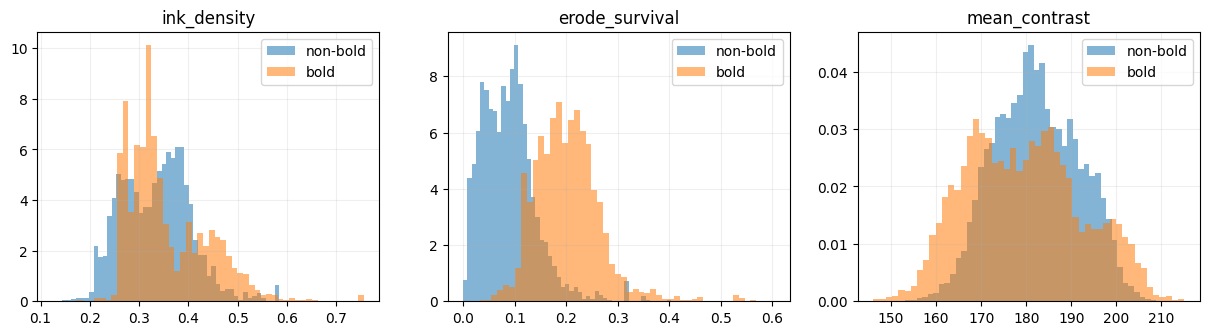

,scope,feature,direction,threshold,precision,recall,f1
2,all cells,erode_survival,>=,0.1496,64.69%,79.49%,71.33%
0,all cells,ink_density,>=,0.2590,22.78%,98.48%,37.00%
5,all cells,mean_contrast,<=,172.2440,38.48%,34.77%,36.53%
1,all cells,ink_density,<=,0.5159,19.63%,95.59%,32.57%
4,all cells,mean_contrast,>=,161.5509,19.23%,93.98%,31.93%
3,all cells,erode_survival,<=,0.2854,19.15%,93.28%,31.77%
8,grammar candidates,erode_survival,>=,0.0793,99.69%,99.10%,99.39%
10,grammar candidates,mean_contrast,>=,157.1513,99.06%,98.28%,98.67%
6,grammar candidates,ink_density,>=,0.2597,99.21%,98.12%,98.66%
11,grammar candidates,mean_contrast,<=,204.8500,99.05%,98.09%,98.57%


Use a visual threshold only if held-out F1 beats the 73.40% private Bold-F1 baseline and remains stable by row role.


In [15]:
# Compare distributions and sweep one threshold per feature on held-out documents.
FEATURES = ['ink_density', 'erode_survival', 'mean_contrast']
fig, axes = plt.subplots(1, len(FEATURES), figsize=(5 * len(FEATURES), 3.5))
for axis, feature in zip(axes, FEATURES):
    for label, frame in bold_visual_df.groupby('is_bold'):
        axis.hist(frame[feature], bins=50, density=True, alpha=0.55, label='bold' if label else 'non-bold')
    axis.set_title(feature)
    axis.legend()
    axis.grid(alpha=0.2)
plt.show()


def visual_prf(expected: pd.Series, predicted: pd.Series) -> dict[str, float]:
    tp = int((expected & predicted).sum())
    fp = int((~expected & predicted).sum())
    fn = int((expected & ~predicted).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    return {'precision': precision, 'recall': recall, 'f1': 2 * precision * recall / max(1e-12, precision + recall)}


# Split by document, never by cell: threshold selection must not see another cell from the evaluation document.
held_out = bold_visual_df.doc_id.str.rsplit('-', n=1).str[-1].astype(int).mod(5).eq(0)
threshold_rows = []
for scope_name, scope in [('all cells', bold_visual_df), ('grammar candidates', bold_visual_df.loc[bold_visual_df.grammar_candidate])]:
    train = scope.loc[~held_out.loc[scope.index]]
    valid = scope.loc[held_out.loc[scope.index]]
    for feature in FEATURES:
        values = train[feature].to_numpy()
        for direction in ('>=', '<='):
            candidates = np.unique(np.quantile(values, np.linspace(0.02, 0.98, 97)))
            scores = []
            for threshold in candidates:
                predicted = train[feature].ge(threshold) if direction == '>=' else train[feature].le(threshold)
                scores.append((visual_prf(train.is_bold, predicted)['f1'], float(threshold)))
            _, threshold = max(scores)
            predicted = valid[feature].ge(threshold) if direction == '>=' else valid[feature].le(threshold)
            threshold_rows.append({'scope': scope_name, 'feature': feature, 'direction': direction, 'threshold': threshold, **visual_prf(valid.is_bold, predicted)})

bold_threshold_scores = pd.DataFrame(threshold_rows).sort_values(['scope', 'f1', 'precision'], ascending=[True, False, False])
display(bold_threshold_scores.style.format({'threshold': '{:.4f}', 'precision': '{:.2%}', 'recall': '{:.2%}', 'f1': '{:.2%}'}))
print('Use a visual threshold only if held-out F1 beats the 73.40% private Bold-F1 baseline and remains stable by row role.')


In [16]:
# Targeted EDA: terminal last rows of one-page M2 tables. Reuses bold_visual_df.
m2_one_page_ids = {item['id'] for item in records if item['difficulty'] == 'M2' and item['page_count'] == 1}
terminal_cells = bold_visual_df.loc[
    bold_visual_df.doc_id.isin(m2_one_page_ids)
    & bold_visual_df.difficulty.eq('M2')
    & bold_visual_df.row_role.eq('last_row')
].copy()

terminal_rows = (terminal_cells.groupby(['doc_id', 'table_id'], as_index=False)
                 .agg(stroke_median=('erode_survival', 'median'),
                      root_cells=('is_bold', 'size'),
                      bold_cells=('is_bold', 'sum')))
terminal_rows['is_bold_row'] = terminal_rows.bold_cells.eq(terminal_rows.root_cells)
terminal_rows['is_mixed_row'] = terminal_rows.bold_cells.gt(0) & ~terminal_rows.is_bold_row
print(f'terminal M2 rows={len(terminal_rows)} | mixed-label rows={int(terminal_rows.is_mixed_row.sum())}')
display(terminal_rows.groupby('is_bold_row')[['stroke_median', 'root_cells', 'bold_cells']].describe().round(4))
if terminal_rows.is_mixed_row.any():
    display(terminal_rows.loc[terminal_rows.is_mixed_row].head(20))


def row_prf(expected: pd.Series, predicted: pd.Series) -> dict[str, float]:
    tp = int((expected & predicted).sum())
    fp = int((~expected & predicted).sum())
    fn = int((expected & ~predicted).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    return {'precision': precision, 'recall': recall, 'f1': 2 * precision * recall / max(1e-12, precision + recall)}


held_out_rows = terminal_rows.doc_id.str.rsplit('-', n=1).str[-1].astype(int).mod(5).eq(0)
train_rows, valid_rows = terminal_rows.loc[~held_out_rows], terminal_rows.loc[held_out_rows]
thresholds = np.unique(np.quantile(train_rows.stroke_median, np.linspace(0.01, 0.99, 99)))
sweep = []
for threshold in thresholds:
    predicted = train_rows.stroke_median.ge(threshold)
    sweep.append({'threshold': float(threshold), **row_prf(train_rows.is_bold_row, predicted)})
best = max(sweep, key=lambda item: (item['f1'], item['precision'], item['recall']))
valid_pred = valid_rows.stroke_median.ge(best['threshold'])
baselines = pd.DataFrame([
    {'method': 'always bold (old M2 rule)', **row_prf(valid_rows.is_bold_row, pd.Series(True, index=valid_rows.index))},
    {'method': 'never bold', **row_prf(valid_rows.is_bold_row, pd.Series(False, index=valid_rows.index))},
    {'method': f"stroke median >= {best['threshold']:.4f}", **row_prf(valid_rows.is_bold_row, valid_pred)},
])
display(baselines.style.format({'precision': '{:.2%}', 'recall': '{:.2%}', 'f1': '{:.2%}'}))
print(f"Recommended M2 last-row threshold: {best['threshold']:.4f} (selected on train documents only).")


terminal M2 rows=422 | mixed-label rows=0


stroke_median                                                  \
                    count    mean     std     min     25%     50%     75%   
is_bold_row                                                                 
True                422.0  0.1821  0.0305  0.1187  0.1606  0.1754  0.1988   

                    root_cells          ...            bold_cells          \
                max      count    mean  ...   75%  max      count    mean   
is_bold_row                             ...                                 
True         0.3233      422.0  7.7559  ...  8.75  9.0      422.0  7.7559   

                                               
                std  min  25%  50%   75%  max  
is_bold_row                                    
True         0.9271  5.0  7.0  8.0  8.75  9.0  

[1 rows x 24 columns]

,method,precision,recall,f1
0,always bold (old M2 rule),100.00%,100.00%,100.00%
1,never bold,0.00%,0.00%,0.00%
2,stroke median >= 0.1260,100.00%,100.00%,100.00%


Recommended M2 last-row threshold: 0.1260 (selected on train documents only).
